In [1]:
import numpy as np
import xarray as xr
import pandas as pd

import glob as glob
import matplotlib.pyplot as mp
import matplotlib.dates as mdates

In [2]:
from dask.distributed import Client
from ncar_jobqueue import NCARCluster

In [3]:
cluster = NCARCluster(project='P93300642',interface='ext', job_extra_directives=[], walltime ='12:00:00')
cluster
cluster.scale(jobs=32)
client = Client(cluster)
client

/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, Future

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/42013/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/42013/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.176:44603,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/42013/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [14]:
# Read in daily data

dir0 = '/glade/derecho/scratch/hannay/archive/'
#dir0 = '/glade/derecho/scratch/bryan/archive/'

dir_fig = '/glade/u/home/rneale/python/python-figs/CAM7_CESM3_dev/'

#case = 'b.e23_alpha16g.BLT1850.ne30_t232.064'
#case = 'b.e23_alpha17f.BLTHIST.ne30_t232.092'
#case = 'b.e23_alpha17f.BLT1850.ne30_g17.POP.096'
#case = 'b.e23_alpha16g.BLT1850.ne30_t232.082b'
#case = 'b.e23_alpha17f.BLT1850.ne30_t232.098ohl'
#case = 'f.cam6_3_160.FMTHIST_ne30.001'


case =  'b.e30_alpha06b.B1850C_LTso.ne30_t232_wgx3.147'


var_name = 'PRECT'
ldiv = False

#lonr_w = 200.
#lonr_e = 270.

# E pacific focus
lonr_w = 220.
lonr_e = 240.



lon_str = str(int(lonr_w))+'E-'+str(int(lonr_e))+'E'
lon_str

'220E-240E'

In [15]:
ovoffset = 0.
voffset = 0.

pvar_name = var_name
if ldiv:
    pvar_name = var_name+'_div'

    

if var_name == 'PRECT':
    clevels = [0,1,2,3,4,5,6,8,10,12,16,18,20]
    cmap = 'terrain_r'
    vscale = 86400.*1000. ; voffset = 0.
    ovscale = 1000.*24.
    ovar_name = 'tp'
    ofile_in = 'precip_era5_dclim_noleap_1x1.nc'

if var_name == 'U850':
    clevels = [-10,-8,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,8,10]
    cmap = 'PiYG_r'
    vscale = 1.
    ovscale = 1.
    ovar_name = 'u'
    ofile_in = 'u850_era5_dclim_noleap_1x1.nc'

if var_name == 'V850':
    if ldiv:
        div_scale = 0.1
        clevels = [-5,-4,-3,-2.5,-2,-1.5,-1,-0.5,0,0.5,1,1.5,2,2.5,3,4,5]
        clevels = [x * div_scale for x in clevels]
        cmap = 'PiYG_r'
    else:
        clevels = [-5,-4,-3,-2.5,-2,-1.5,-1,-0.5,0,0.5,1,1.5,2,2.5,3,4,5]
        cmap = 'PiYG_r'
    vscale = 1.
    ovscale = 1.
    ovar_name = 'v'
    ofile_in = 'v850_era5_dclim_noleap_1x1.nc'
    
if var_name == 'dV850':
    clevels = [-5,-4,-3,-2.5,-2,-1.5,-1,-0.5,0,0.5,1,1.5,2,2.5,3,4,5]
    cmap = 'PiYG_r'
    vscale = 1.
    ovscale = 1.
    ovar_name = 'v'
    ofile_in = 'v850_era5_dclim_noleap_1x1.nc'


if var_name == 'LHFLX':
    clevels = [180,190,200,210,220,230,240,250,260,270,280,290,300,310]
    cmap = 'RdYlBu_r'
    vscale = 24.
    ovscale = 1.
    ovar_name = 'slhf'
    ofile_in = 'lhflx_era5_dclim_noleap_1x1.nc'

if var_name == 'PSL':
    clevels = [180,190,200,210,220,230,240,250,260,270,280,290,300,310]
    cmap = 'RdYlBu_r'
    vscale = 0.01
    ovscale = 1.
    ovar_name = 'slhf'
    ofile_in = 'lhflx_era5_dclim_noleap_1x1.nc'

if var_name == 'TS':
#    clevels = [290,292,294,296,297,298,298.5,299,299.5,300,300.5,301,301.5,302]
    clevels = [24,25,26,27,27.25,27.5,27.75,28,28.25,28.5,28.75,29,29.25,29.5,29.75,30]
    cmap = 'jet'
    vscale = 1. ; voffset = -273.16
   
## ERA5
    ovar_name = 'ts'
    ofile_in = 'ts_era5_dclim_noleap_1x1.nc'
    ovscale = 1. ; ovoffset = -273.16

## NOAA
#    ovar_name = 'SST_cpl'
#    ofile_in = 'sst_reynolds_daily_0.9x1.25_yrs1982-2018_timeseries_c20190822.nc'
#    ovscale = 1. ; ovoffset = 1
print(ofile_in)

precip_era5_dclim_noleap_1x1.nc


In [16]:
dir_in = dir0+case+'/atm/hist/'
files_stub = dir_in+case+'.cam.h2a.cam.*nc' 
print(files_stub)

files_list = sorted(glob.glob(files_stub))
df_case = xr.open_mfdataset(files_list, engine="netcdf4",parallel=True,chunks={"time": 365})

/glade/derecho/scratch/hannay/archive/b.e30_alpha06b.B1850C_LTso.ne30_t232_wgx3.147/atm/hist/b.e30_alpha06b.B1850C_LTso.ne30_t232_wgx3.147.cam.h2a.*nc


In [17]:
df_case

<xarray.Dataset> Size: 93GB
Dimensions:       (time: 35040, lat: 192, lev: 58, ilev: 59, nbnd: 2, lon: 288,
                   trop_pref: 58, trop_prefi: 59, trop_cld_lev: 58)
Coordinates:
  * lat           (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon           (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.3 357.5 358.8
  * lev           (lev) float64 464B 3.018 5.445 9.087 ... 983.2 991.2 997.5
  * ilev          (ilev) float64 472B 2.055 3.98 6.909 ... 987.4 995.1 1e+03
  * trop_pref     (trop_pref) float64 464B 3.018 5.445 9.087 ... 991.2 997.5
  * trop_prefi    (trop_prefi) float64 472B 2.055 3.98 6.909 ... 995.1 1e+03
  * trop_cld_lev  (trop_cld_lev) float64 464B 3.018 5.445 9.087 ... 991.2 997.5
  * time          (time) object 280kB 0001-01-01 12:00:00 ... 0096-12-31 12:0...
Dimensions without coordinates: nbnd
Data variables: (12/27)
    w             (time, lat) float64 54MB dask.array<chunksize=(20, 192), meta=np.ndarray>
    hyam          (time, lev) float64 16MB dask.array<chunksize=(20, 58), meta=np.ndarray>
    hybm          (time, lev) float64 16MB dask.array<chunksize=(20, 58), meta=np.ndarray>
    hyai          (time, ilev) float64 17MB dask.array<chunksize=(20, 59), meta=np.ndarray>
    hybi          (time, ilev) float64 17MB dask.array<chunksize=(20, 59), meta=np.ndarray>
    date          (time) int32 140kB dask.array<chunksize=(20,), meta=np.ndarray>
    ...            ...
    TS            (time, lat, lon) float32 8GB dask.array<chunksize=(20, 192, 288), meta=np.ndarray>
    U200          (time, lat, lon) float32 8GB dask.array<chunksize=(20, 192, 288), meta=np.ndarray>
    U850          (time, lat, lon) float32 8GB dask.array<chunksize=(20, 192, 288), meta=np.ndarray>
    V200          (time, lat, lon) float32 8GB dask.array<chunksize=(20, 192, 288), meta=np.ndarray>
    V850          (time, lat, lon) float32 8GB dask.array<chunksize=(20, 192, 288), meta=np.ndarray>
    Z500          (time, lat, lon) float32 8GB dask.array<chunksize=(20, 192, 288), meta=np.ndarray>
Attributes:
    interp_type:       bilinear
    interp_outputgri:  equally spaced with poles
    Conventions:       CF-1.0
    source:            CAM
    case:              b.e30_alpha06b.B1850C_LTso.ne30_t232_wgx3.147
    logname:           hannay
    host:              dec1539
    initial_file:      b.e30_alpha06b.B1850C_LTso.ne30_t232_wgx3.130.cam.i.00...
    topography_file:   /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/s...
    model_doi_url:     not_set
    time_period_freq:  day_1

In [18]:
var_in = df_case[var_name]

# Ensure the time coordinate is in DatetimeIndex
#var_in['time'] = pd.to_datetime(var_in['time'].values)

# Group by day of the year
doy_grouped = var_in.groupby('time.dayofyear')

# Calculate the mean for each day of the year to get the climatology
doy_climatology = doy_grouped.mean(dim='time')

# Reconstruct the annual cycle (optional)
annual_cycle = doy_climatology.sel(dayofyear=var_in['time'].dt.dayofyear)

# Select the longitudinal range (200 to 270 degrees east)
selected_lon = doy_climatology.sel(lon=slice(lonr_w, lonr_e))
print(selected_lon.max)
# Compute the zonal average
zonal_average = selected_lon.mean(dim='lon')
zonal_average = zonal_average*vscale+voffset

# Save the climatology to a new NetCDF file
#doy_climatology.to_netcdf('doy_annual_climatology.nc')


<bound method DataArrayAggregations.max of <xarray.DataArray 'PRECT' (dayofyear: 365, lat: 192, lon: 16)> Size: 4MB
dask.array<getitem, shape=(365, 192, 16), dtype=float32, chunksize=(1, 192, 16), chunktype=numpy.ndarray>
Coordinates:
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 128B 221.3 222.5 223.8 225.0 ... 237.5 238.8 240.0
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Attributes:
    units:         m/s
    long_name:     Total (convective and large-scale) precipitation rate (liq...
    cell_methods:  time: mean>


<xarray.DataArray 'PRECT' (dayofyear: 365, lat: 192)> Size: 280kB
dask.array<getitem, shape=(365, 192), dtype=float32, chunksize=(9, 192), chunktype=numpy.ndarray>
Coordinates:
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365


/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/distributed/client.py:3383: UserWarning: Sending large graph of size 9.71 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


ValueError: Moving window (=9) must between 1 and 8, inclusive

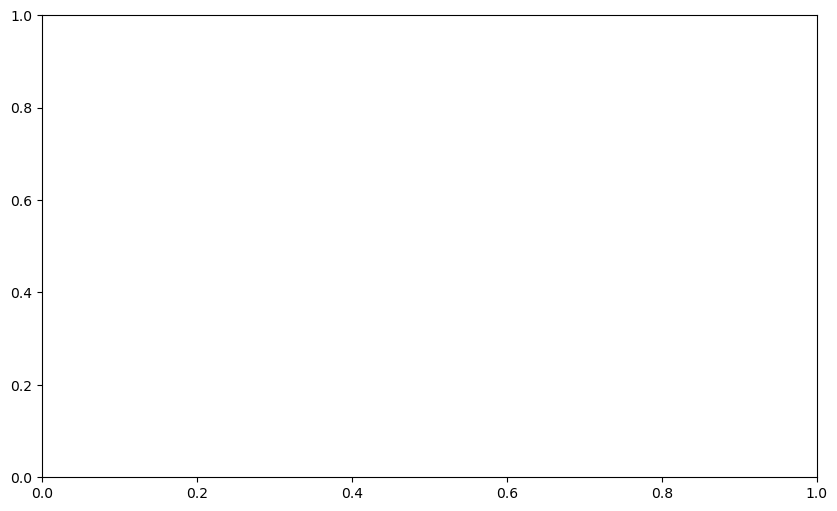

In [21]:

fig, ax3 = mp.subplots(figsize=(10, 6))

if ldiv:
    zonal_average = zonal_average.differentiate("lat")

zonal_raverage_c3 = zonal_average.rolling(dayofyear=9, center=True).mean()
print(zonal_raverage_c3)

zonal_raverage_c3.plot.contourf(cmap=cmap, levels=clevels)

ax3.set_title(case+' ('+lon_str+')')
ax3.set_ylabel('Day of Year')
ax3.set_xlabel('Latitude')
ax3.set_xlim([-25.0, 25.0])
ax3.yaxis.set_major_locator(mdates.MonthLocator())
ax3.yaxis.set_major_formatter(mdates.DateFormatter('%b'))
mp.savefig(dir_fig+case+'_'+pvar_name+'_epac_'+lon_str+'_itcz.png', dpi=100, bbox_inches='tight')
mp.show()

In [ ]:
## Obs.

ocase = 'ERA5'
odir = '/glade/derecho/scratch/rneale/ERA5/dmean/1deg/'

#ocase = 'NOAA'
#odir = '/glade/campaign/cesm/cesmdata/cseg/inputdata/atm/cam/sst/'


file_all = odir+ofile_in

print(file_all)
df_obs = xr.open_dataset(file_all, engine="netcdf4",decode_times = True)


In [ ]:
# Compute the zonal average


ovar_in = df_obs[ovar_name]


# For NOAA need to calculate mean annaual cycle.
if ocase == 'NOAA':
    odoy_grouped = ovar_in.groupby('time.dayofyear')
    
    # Calculate the mean for each day of the year to get the climatology
    odoy_climatology = odoy_grouped.mean(dim='time')
    
    # Reconstruct the annual cycle (optional)
    oannual_cycle = odoy_climatology.sel(dayofyear=ovar_in['time'].dt.dayofyear)

else:

    odoy_climatology = ovar_in 
    
# Select the longitudinal range (200 to 270 degrees east)
oselected_lon = odoy_climatology.sel(lon=slice(lonr_w, lonr_e))
  
# Compute the zonal average
ozonal_average = oselected_lon.mean(dim='lon')

ozonal_average.values
ozonal_average = ozonal_average*ovscale+ovoffset











# Save the climatology to a new NetCDF file
#doy_climatology.to_netcdf('odoy_annual_climatology.nc')

In [ ]:
fig, axo = mp.subplots(figsize=(10, 6))

if ldiv:
    ozonal_average = ozonal_average.differentiate("lat")

print(ozonal_average)

ozonal_raverage = ozonal_average.rolling(time=10, center=True).mean()
ozonal_raverage.plot.contourf(cmap=cmap, levels=clevels)
axo.set_title('ERA5 ('+lon_str+')')
axo.set_ylabel('Day of Year')
axo.set_xlabel('Latitude')
axo.set_xlim([-25.0, 25.0])
axo.yaxis.set_major_locator(mdates.MonthLocator())
axo.yaxis.set_major_formatter(mdates.DateFormatter('%b'))
                             
mp.savefig(dir_fig+ocase+'_'+pvar_name+'_epac_'+lon_str+'_itcz.png', dpi=100, bbox_inches='tight')
mp.show()

In [ ]:
lcase = 'b.e21.BHISTcmip6.f09_g17.LE2-1001.001'
ldir0 = '/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/tseries/day_1/'

ldir_in = ldir0+var_name+'/'
lfiles_stub = ldir_in+lcase+'.cam.h1.*.18*nc' 


lfiles_list = sorted(glob.glob(lfiles_stub))
print(lfiles_list)
df_lcase = xr.open_mfdataset(lfiles_list, engine="netcdf4",parallel=True,chunks={"time": 365})
df_lcase

In [ ]:
lvar_in = df_lcase[var_name]

# Ensure the time coordinate is in DatetimeIndex
#var_in['time'] = pd.to_datetime(var_in['time'].values)

# Group by day of the year
ldoy_grouped = lvar_in.groupby('time.dayofyear')

# Calculate the mean for each day of the year to get the climatology
ldoy_climatology = ldoy_grouped.mean(dim='time')

# Reconstruct the annual cycle (optional)
lannual_cycle = ldoy_climatology.sel(dayofyear=lvar_in['time'].dt.dayofyear)

# Select the longitudinal range (200 to 270 degrees east)
lselected_lon = ldoy_climatology.sel(lon=slice(lonr_w, lonr_e))

# Compute the zonal average
lzonal_average = lselected_lon.mean(dim='lon')
print(voffset,vscale)
lzonal_average.values
lzonal_average = lzonal_average*vscale+voffset
lzonal_average

In [ ]:
# Save the climatology to a new NetCDF file
#doy_climatology.to_netcdf('doy_annual_climatology.nc')

if ldiv:
    lzonal_average = lzonal_average.differentiate("lat")

lzonal_raverage = lzonal_average.rolling(dayofyear=10, center=True).mean()

In [ ]:


fig,axl= mp.subplots(figsize=(10, 6))



lzonal_raverage.plot.contourf(cmap=cmap, levels=clevels)

axl.set_title('CESM2 ('+lon_str+')')
axl.set_ylabel('Day of Year')
axl.set_xlabel('Latitude')
axl.set_xlim([-25.0, 25.0])

axl.yaxis.set_major_locator(mdates.MonthLocator())
axl.yaxis.set_major_formatter(mdates.DateFormatter('%b'))

mp.savefig(dir_fig+lcase+'_'+pvar_name+'_epac_itcz_'+lon_str+'.png', dpi=100, bbox_inches='tight')
mp.show()